# Assignment 5.1
## Build an Explainable Bayesian Network for Heart Failure Prediction

In real medical AI systems today, doctors and regulators frequently reject black-box models (even if they are slightly more accurate) because they cannot explain why a patient was classified as high-risk. Bayesian Networks solve this problem and are still used in clinical decision support tools.

Your assignment is to use the Heart Failure Prediction dataset (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) to do the following:

In [1]:
# pandas manages the table; NumPy supplies numerical arrays and calculations.
import pandas as pd
import numpy as np

# Load the CSV file into a pandas DataFrame named df.
df = pd.read_csv("heart.csv")

# Preview the first 16 patients, then confirm the complete dataset dimensions.
display(df.head(16))
print("Rows and columns:", df.shape)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


Rows and columns: (918, 12)


1. Exploratory Data Analysis
    * Produce at least four insightful plots
    * Write 3–5 sentences summarising the most important risk factors you observe

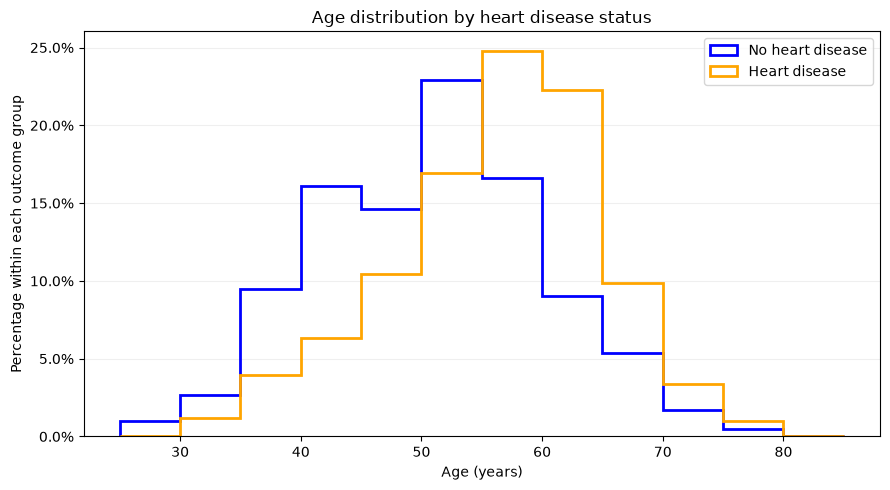

In [2]:
# Matplotlib creates the figures; PercentFormatter displays values with percent signs.
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Separate ages according to whether heart disease is present.
ages_no_disease = df.loc[df["HeartDisease"] == 0, "Age"]
ages_disease = df.loc[df["HeartDisease"] == 1, "Age"]

# Use the same age intervals for both groups.
bins = list(range(25, 86, 5))

# Create one figure and one plotting area that is 9 inches wide by 5 inches tall.
fig, ax = plt.subplots(figsize=(9, 5))

# Draw the no-disease distribution. The weights convert counts to within-group percentages.
ax.hist(
    ages_no_disease,
    bins=bins,
    weights=[100 / len(ages_no_disease)] * len(ages_no_disease),
    histtype="step",
    linewidth=2,
    color="blue",
    label="No heart disease",
)

# Draw the disease distribution with the same bins so the two shapes are comparable.
ax.hist(
    ages_disease,
    bins=bins,
    weights=[100 / len(ages_disease)] * len(ages_disease),
    histtype="step",
    linewidth=2,
    color="orange",
    label="Heart disease",
)

# Add labels, format the vertical axis as percentages, and include a legend and grid.
ax.set_title("Age distribution by heart disease status")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Percentage within each outcome group")
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend()
ax.grid(axis="y", alpha=0.2)

# Prevent label clipping, display the figure, and release it from memory afterward.
plt.tight_layout()
plt.show()
plt.close(fig)

### Plot 2: Heart-disease frequency by chest-pain type

This plot compares the percentage of patients with heart disease within each chest-pain category. The labels also show the number of positive cases and the total number of patients in each category.

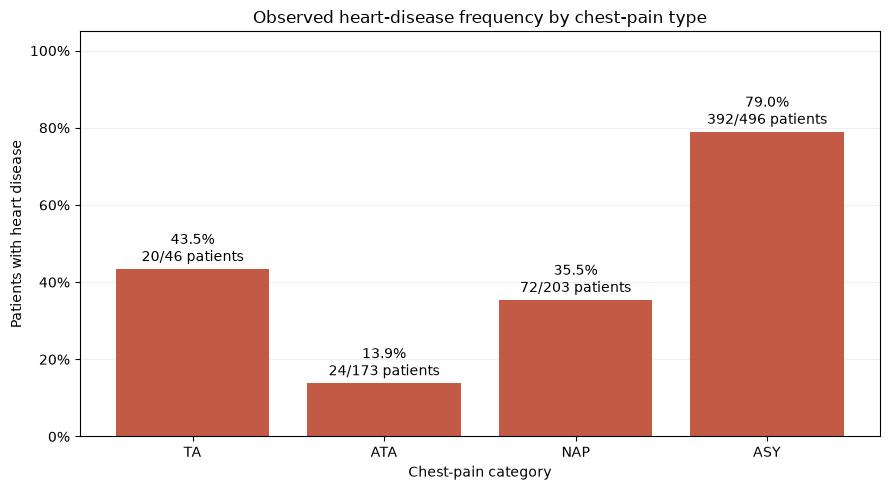

In [3]:
# Set a consistent clinical category order for the horizontal axis.
chest_pain_order = ["TA", "ATA", "NAP", "ASY"]

# For every chest-pain category, calculate disease rate, positive cases, and total patients.
# Because HeartDisease is coded 0/1, its mean is the proportion with disease.
chest_pain_stats = (
    df.groupby("ChestPainType")["HeartDisease"]
      .agg(["mean", "sum", "count"])
      .reindex(chest_pain_order)
)

# Create one figure and one plotting area that is 9 inches wide by 5 inches tall.
fig, ax = plt.subplots(figsize=(9, 5))
# Plot each category's disease percentage as a bar.
bars = ax.bar(
    chest_pain_stats.index,
    chest_pain_stats["mean"] * 100,
    color="#C35A45",
)

# Place the percentage and numerator/denominator above every bar.
for bar, row in zip(bars, chest_pain_stats.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{row.mean:.1%}\n{int(row.sum)}/{int(row.count)} patients",
        ha="center",
    )

# Label and format the plot; the y-limit leaves room for the annotations.
ax.set_title("Observed heart-disease frequency by chest-pain type")
ax.set_xlabel("Chest-pain category")
ax.set_ylabel("Patients with heart disease")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

# Prevent label clipping, display the figure, and release it from memory afterward.
plt.tight_layout()
plt.show()
plt.close(fig)

### Plot 3: ST slope and exercise-induced angina

This heatmap considers two features together. Each cell shows the observed heart-disease frequency and the number of patients with that evidence combination.

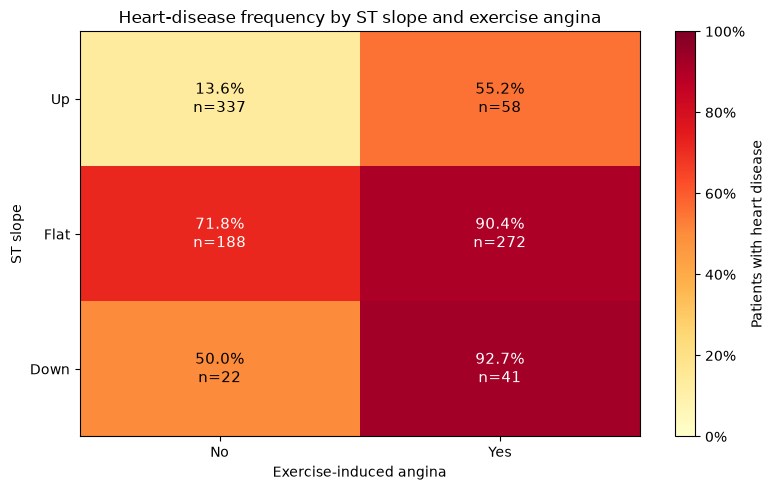

In [4]:
# Fix the row and column order so the heatmap is easy to read.
st_order = ["Up", "Flat", "Down"]
angina_order = ["N", "Y"]

# Calculate the observed disease proportion for each ST-slope/angina combination.
heart_disease_rates = df.pivot_table(
    index="ST_Slope",
    columns="ExerciseAngina",
    values="HeartDisease",
    aggfunc="mean",
).reindex(index=st_order, columns=angina_order)

# Count patients in each combination so small groups are visible.
group_counts = df.pivot_table(
    index="ST_Slope",
    columns="ExerciseAngina",
    values="HeartDisease",
    aggfunc="count",
).reindex(index=st_order, columns=angina_order)

# Create the heatmap and map 0% to 100% onto a yellow-to-red color scale.
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(
    heart_disease_rates.to_numpy() * 100,
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    aspect="auto",
)

# Write the exact disease percentage and sample size inside every heatmap cell.
for row in range(len(st_order)):
    for column in range(len(angina_order)):
        rate = heart_disease_rates.iloc[row, column]
        count = int(group_counts.iloc[row, column])
        ax.text(
            column,
            row,
            f"{rate:.1%}\nn={count}",
            ha="center",
            va="center",
            color="white" if rate > 0.65 else "black",
            fontsize=11,
        )

# Replace numeric matrix positions with meaningful axis labels and add a color legend.
ax.set_xticks([0, 1], ["No", "Yes"])
ax.set_yticks(range(len(st_order)), st_order)
ax.set_title("Heart-disease frequency by ST slope and exercise angina")
ax.set_xlabel("Exercise-induced angina")
ax.set_ylabel("ST slope")
fig.colorbar(
    image,
    ax=ax,
    format=PercentFormatter(100),
    label="Patients with heart disease",
)

# Prevent label clipping, display the figure, and release it from memory afterward.
plt.tight_layout()
plt.show()
plt.close(fig)

### Plot 4: Maximum achieved heart rate

This box plot compares the median, middle 50%, overall spread, and potential outliers in maximum achieved heart rate for the two outcome groups.

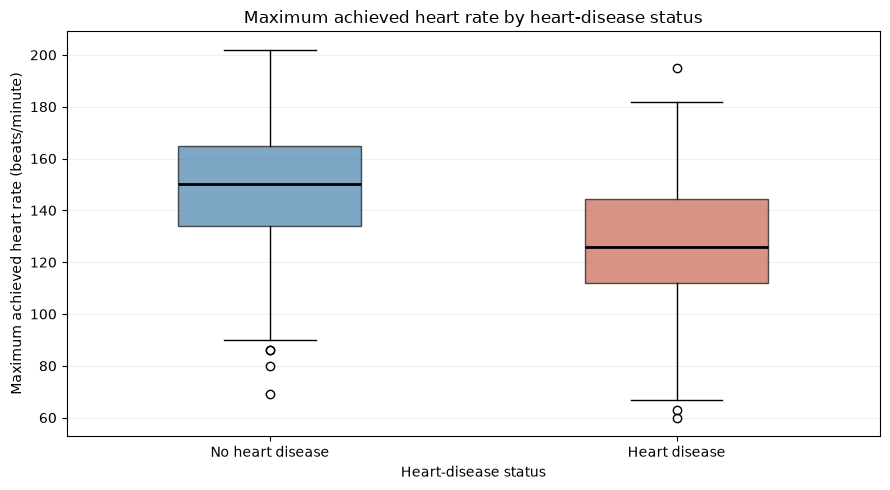

In [5]:
# Split maximum heart-rate measurements into no-disease and disease groups.
max_hr_groups = [
    df.loc[df["HeartDisease"] == outcome, "MaxHR"]
    for outcome in [0, 1]
]

# Create one figure and one plotting area that is 9 inches wide by 5 inches tall.
fig, ax = plt.subplots(figsize=(9, 5))
# Draw box plots showing medians, middle 50% ranges, whiskers, and possible outliers.
boxplots = ax.boxplot(
    max_hr_groups,
    tick_labels=["No heart disease", "Heart disease"],
    patch_artist=True,
    widths=0.45,
    medianprops={"color": "black", "linewidth": 2},
)

# Give the two outcome groups different fill colors.
for box, color in zip(boxplots["boxes"], ["#3979A8", "#C35A45"]):
    box.set_facecolor(color)
    box.set_alpha(0.65)

# Add descriptive labels and a horizontal reference grid.
ax.set_title("Maximum achieved heart rate by heart-disease status")
ax.set_xlabel("Heart-disease status")
ax.set_ylabel("Maximum achieved heart rate (beats/minute)")
ax.grid(axis="y", alpha=0.2)

# Prevent label clipping, display the figure, and release it from memory afterward.
plt.tight_layout()
plt.show()
plt.close(fig)

Patients with heart disease tended to be older, with a median age of 57 years compared with 51 years among patients without heart disease. The asymptomatic chest-pain category had a higher observed disease frequency (79.0%) than the other chest-pain categories. Flat ST slope combined with exercise-induced angina was associated with a particularly high disease frequency of 90.4%. Patients with heart disease also had a lower median maximum achieved heart rate, at 126 beats per minute compared with 150 in the group without disease. These patterns identify potential predictors in this dataset, but they show associations rather than proving that these factors cause heart disease.

2. Bayesian Network Structure Learning
    * Using pgmpy, try at least two different structure-learning algorithms and visualize both resulting graphs
    * Choose the one that makes the most clinical sense, use it for the rest of the project, and briefly justify your final choice (2-4 sentences)

In [6]:

# train_test_split reserves unseen patients for a realistic classifier evaluation.
from sklearn.model_selection import train_test_split

# Keep the existing categorical variables and the target.
model_data = df[
    [
        "Sex", "ChestPainType", "FastingBS",
        "RestingECG", "ST_Slope", "HeartDisease"
    ]
].copy()

# Match the assignment's use of 0 and 1.
# Convert Yes/No into the 1/0 states used by the assignment queries.
model_data["ExerciseAngina"] = df["ExerciseAngina"].map(
    {"N": 0, "Y": 1}
)

# Define categories for numeric measurements.
# Each entry contains bin boundaries followed by the labels assigned to those intervals.
bin_definitions = {
    "Age": (
        [float("-inf"), 40, 60, float("inf")],
        ["<40", "40-59", "60+"]
    ),
    "RestingBP": (
        [float("-inf"), 120, 140, float("inf")],
        ["Normal", "Elevated", "High"]
    ),
    "Cholesterol": (
        [float("-inf"), 200, 240, float("inf")],
        ["Normal", "Borderline", "High"]
    ),
    "MaxHR": (
        [float("-inf"), 120, 160, float("inf")],
        ["Low", "Medium", "High"]
    ),
    "Oldpeak": (
        [float("-inf"), 1, 2, float("inf")],
        ["Low", "Medium", "High"]
    ),
}

# Apply the matching bin definition to each continuous measurement.
for column, (boundaries, labels) in bin_definitions.items():
    values = df[column].copy()

    # Treat suspicious zero measurements as unknown.
    if column in ["RestingBP", "Cholesterol"]:
        values = values.mask(values == 0)

    # pd.cut assigns each measurement to an interval. right=False includes the lower boundary.
    # Converting to object allows missing values to be replaced with the label Unknown.
    model_data[column + "_bin"] = (
        pd.cut(values, bins=boundaries, labels=labels, right=False)
        .astype(object)
        .fillna("Unknown")
    )

# Explicit categorical types work with pgmpy 1.0.0.
for column in model_data.columns:
    model_data[column] = model_data[column].astype("category")

# Reserve patients for classifier evaluation later.
# Use 70% for learning and 30% for evaluation. Stratification preserves the target balance,
# while random_state=42 makes the split reproducible.
train_data, test_data = train_test_split(
    model_data,
    test_size=0.30,
    random_state=42,
    stratify=model_data["HeartDisease"],
)

# Check the transformed variables and report the size of each split.
display(model_data.head())
print("Training patients:", len(train_data))
print("Test patients:", len(test_data))

,Sex,ChestPainType,FastingBS,RestingECG,ST_Slope,HeartDisease,ExerciseAngina,Age_bin,RestingBP_bin,Cholesterol_bin,MaxHR_bin,Oldpeak_bin
0,M,ATA,0,Normal,Up,0,0,40-59,High,High,High,Low
1,F,NAP,0,Normal,Flat,1,0,40-59,High,Normal,Medium,Medium
2,M,ATA,0,ST,Up,0,0,<40,Elevated,High,Low,Low
3,F,ASY,0,Normal,Flat,1,1,40-59,Elevated,Borderline,Low,Medium
4,M,NAP,0,Normal,Up,0,0,40-59,High,Normal,Medium,Low


Training patients: 642
Test patients: 276


In [7]:
# Import pgmpy's score-based search, tree search, and structural constraint tools.
from pgmpy.estimators import (
    HillClimbSearch,
    TreeSearch,
    ExpertKnowledge,
)

# Prevent arrows pointing into age or sex.
# These demographic attributes precede the clinical findings.
# Generate every possible incoming edge to Age_bin or Sex and mark it as forbidden.
forbidden_edges = [
    (source, destination)
    for source in model_data.columns
    for destination in ["Age_bin", "Sex"]
    if source != destination
]

# Algorithm 1: Hill climbing with BIC.
# Search for a high-BIC directed acyclic graph. BIC rewards fit while penalizing complexity.
# max_indegree limits every node to at most three direct parents.
hill_graph = HillClimbSearch(train_data).estimate(
    scoring_method="bic-d",
    max_indegree=3,
    expert_knowledge=ExpertKnowledge(
        forbidden_edges=forbidden_edges
    ),
    show_progress=False,
)

# Algorithm 2: Chow-Liu tree.
# Learn a Chow-Liu maximum-information tree directed outward from Age_bin.
tree_graph = TreeSearch(
    train_data,
    root_node="Age_bin",
    n_jobs=1,
).estimate(
    estimator_type="chow-liu",
    show_progress=False,
)

# Learn TAN: HeartDisease points to every predictor, plus a dependency tree among predictors.
tan_graph = TreeSearch(
    train_data,
    root_node="Age_bin",
    n_jobs=1,
).estimate(
    estimator_type="tan",
    class_node="HeartDisease",
    show_progress=False,
)

# Ensure every variable appears, including isolated nodes.
# Explicitly retain isolated variables that might not receive any learned edge.
hill_graph.add_nodes_from(model_data.columns)
tree_graph.add_nodes_from(model_data.columns)
tan_graph.add_nodes_from(model_data.columns)

# Print each directed edge as a (parent, child) pair for inspection.
print("Hill-climbing connections:")
print(sorted(hill_graph.edges()))

print("\nChow-Liu connections:")
print(sorted(tree_graph.edges()))

print("\nTAN connections:")
print(sorted(tan_graph.edges()))


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


Hill-climbing connections:
[('Age_bin', 'Oldpeak_bin'), ('Age_bin', 'RestingBP_bin'), ('Age_bin', 'RestingECG'), ('Cholesterol_bin', 'FastingBS'), ('ExerciseAngina', 'ChestPainType'), ('ExerciseAngina', 'MaxHR_bin'), ('HeartDisease', 'ChestPainType'), ('HeartDisease', 'Cholesterol_bin'), ('HeartDisease', 'ExerciseAngina'), ('HeartDisease', 'FastingBS'), ('Oldpeak_bin', 'ExerciseAngina'), ('Oldpeak_bin', 'ST_Slope'), ('ST_Slope', 'HeartDisease'), ('ST_Slope', 'MaxHR_bin'), ('Sex', 'HeartDisease')]

Chow-Liu connections:
[('Age_bin', 'MaxHR_bin'), ('Age_bin', 'RestingBP_bin'), ('Cholesterol_bin', 'FastingBS'), ('Cholesterol_bin', 'RestingECG'), ('HeartDisease', 'ChestPainType'), ('HeartDisease', 'Cholesterol_bin'), ('HeartDisease', 'ExerciseAngina'), ('HeartDisease', 'Sex'), ('MaxHR_bin', 'ST_Slope'), ('ST_Slope', 'HeartDisease'), ('ST_Slope', 'Oldpeak_bin')]

TAN connections:
[('Age_bin', 'MaxHR_bin'), ('Age_bin', 'RestingBP_bin'), ('Age_bin', 'RestingECG'), ('Cholesterol_bin', 'Fasting

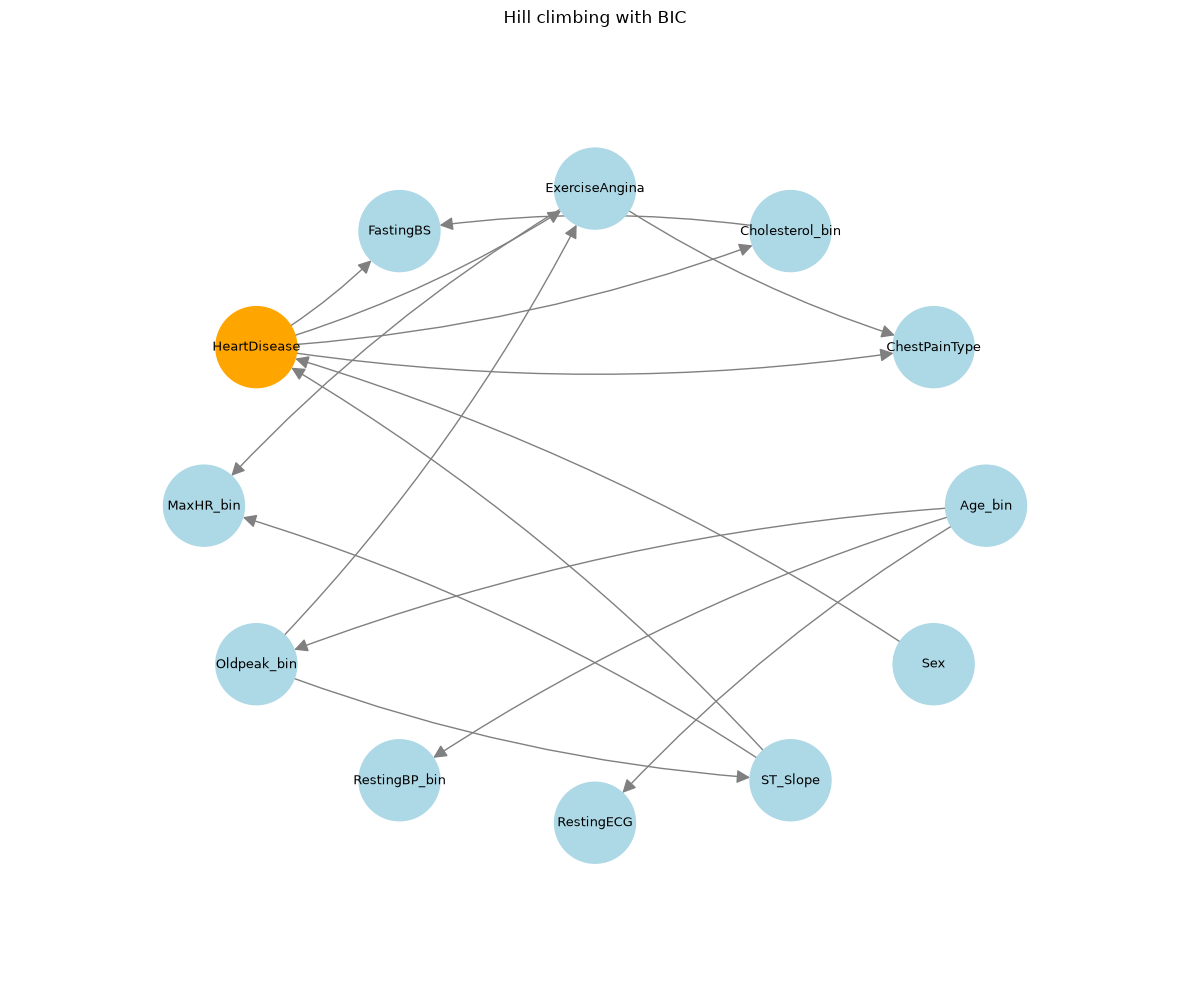

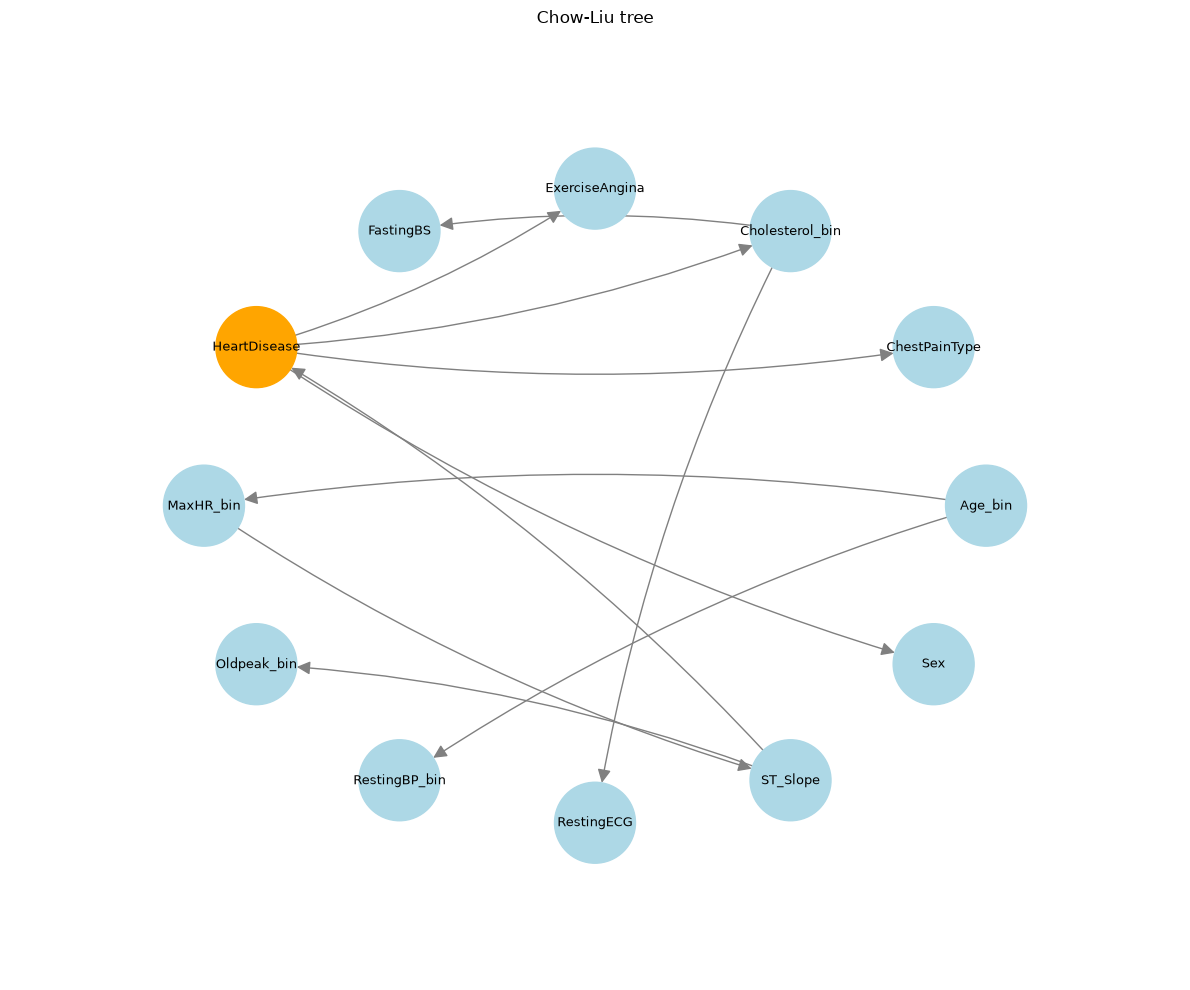

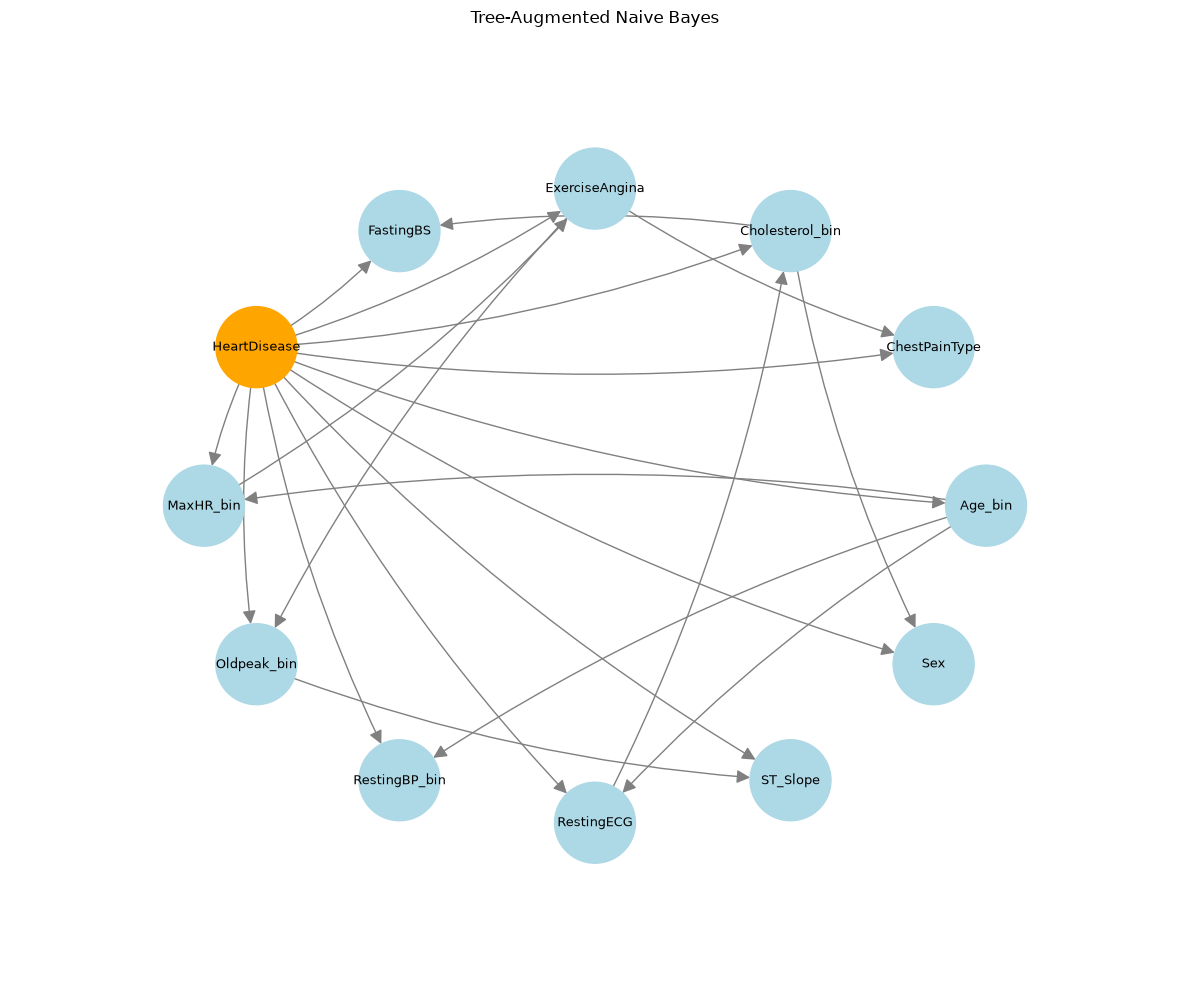

In [8]:
# NetworkX lays out and draws the learned directed graphs; Matplotlib displays them.
import networkx as nx
import matplotlib.pyplot as plt

# Keep identical node positions in all three graphs so their connections are easier to compare.
positions = nx.circular_layout(sorted(model_data.columns))

# Pair each learned graph with the title shown above its visualization.
graphs = [
    ("Hill climbing with BIC", hill_graph),
    ("Chow-Liu tree", tree_graph),
    ("Tree-Augmented Naive Bayes", tan_graph)
]

# Draw one figure for each candidate structure.
for title, graph in graphs:
    fig, ax = plt.subplots(figsize=(12, 10))

    # Highlight the target in orange and draw all predictor nodes in light blue.
    node_colors = [
        "orange" if node == "HeartDisease" else "lightblue"
        for node in graph.nodes()
    ]

    # Draw labeled nodes and directed arrows using the shared circular positions.
    nx.draw_networkx(
        graph,
        pos=positions,
        ax=ax,
        node_color=node_colors,
        node_size=3400,
        font_size=9,
        arrows=True,
        arrowsize=20,
        edge_color="gray",
        connectionstyle="arc3,rad=0.08",
    )

    # Add the algorithm name, padding, and hide ordinary numeric axes.
    ax.set_title(title)
    ax.margins(0.18)
    ax.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

I chose the constrained Hill Climbing network because it allows heart disease to be related to several risk factors and test results at the same time. Compared with Chow–Liu, it does not force every variable into one tree, so it can represent multiple direct dependencies. I also did not select TAN because TAN forces HeartDisease to be a parent of every predictor, including fixed characteristics such as age and sex, which is useful for classification but less clinically intuitive. The arrows are statistical dependencies used by the model and should not be interpreted as proven cause-and-effect relationships.

3. Parameter Learning & Clinical Inference
    * Fit the conditional probability tables (CPTs) on the full data, then perform and interpret these five queries (show the numerical result + 2–3 sentence interpretation for each):

        **a) P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat'**
      
        **b) Same patient but with ExerciseAngina=1**
      
        **c) P(HeartDisease=1 | Cholesterol_bin='High', MaxHR_bin='Low')**
      
        **d) P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0)**
      
        **e) Full diagnostic: P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1, Oldpeak_bin='High')**

In [9]:
# Import the discrete-network model, smoothed CPT estimator, and exact inference engine.
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from IPython.display import display, Markdown

# Record the possible categories for every variable.
# Save the complete list of allowed states so rare categories are not accidentally omitted.
state_names = {
    column: model_data[column].cat.categories.tolist()
    for column in model_data.columns
}

# Build a Bayesian network using the hill-climbing structure.
# Copy the selected hill-climbing structure into a model that can hold CPTs.
hill_model = DiscreteBayesianNetwork(hill_graph.edges())
hill_model.add_nodes_from(model_data.columns)

# Fit the CPTs using the full dataset.
# Estimate every CPT from all 918 patients, as required for the five clinical queries.
# BDeU contributes small symmetric pseudo-counts and avoids unsupported zero probabilities.
hill_model.fit(
    model_data,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=5,
    state_names=state_names,
    n_jobs=1,
)

# Stop immediately if any CPT is missing, malformed, or inconsistent with the graph.
assert hill_model.check_model()

# Display the CPT for HeartDisease.
print("HeartDisease conditional probability table:")
print(hill_model.get_cpds("HeartDisease"))

# Create the inference engine.
# Variable elimination answers conditional-probability questions by summing over unknown variables.
inference = VariableElimination(hill_model)

# Return only the posterior probability for the HeartDisease=1 state.
def heart_disease_probability(evidence):
    result = inference.query(
        variables=["HeartDisease"],
        evidence=evidence,
        show_progress=False,
    )
    return float(result.get_value(HeartDisease=1))

# Define the five assignment queries.
# Store the exact evidence requested for queries a through e.
queries = {
    "a": {
        "Age_bin": "60+",
        "ST_Slope": "Flat",
    },
    "b": {
        "Age_bin": "60+",
        "ST_Slope": "Flat",
        "ExerciseAngina": 1,
    },
    "c": {
        "Cholesterol_bin": "High",
        "MaxHR_bin": "Low",
    },
    "d": {
        "ChestPainType": "ATA",
        "ExerciseAngina": 0,
    },
    "e": {
        "Age_bin": "60+",
        "ST_Slope": "Flat",
        "ExerciseAngina": 1,
        "Oldpeak_bin": "High",
    },
}

# Calculate each probability.
# Run every query and save its posterior probability under the matching letter.
probabilities = {
    label: heart_disease_probability(evidence)
    for label, evidence in queries.items()
}

# Display a results table.
# Organize the evidence and results into a readable summary table.
results_table = pd.DataFrame(
    {
        "Query": list(queries.keys()),
        "Evidence": [str(evidence) for evidence in queries.values()],
        "P(HeartDisease=1)": [
            probabilities[label] for label in queries
        ],
        "Percentage": [
            f"{probabilities[label]:.2%}" for label in queries
        ],
    }
).set_index("Query")

display(results_table)

# Calculate changes between related queries.
change_b = 100 * (probabilities["b"] - probabilities["a"])
change_e = 100 * (probabilities["e"] - probabilities["b"])

# Generate the required written interpretations.
# Build two-sentence explanations using the calculated values instead of hard-coded numbers.
interpretations = {
    "a": (
        f"For a patient aged 60 or older with a Flat ST slope, the "
        f"model estimates a {probabilities['a']:.2%} probability of "
        f"heart disease. Other patient features remain unspecified, "
        f"so the network averages over their possible values."
    ),

    "b": (
        f"After adding exercise-induced angina, the estimated "
        f"probability is {probabilities['b']:.2%}. This is "
        f"{abs(change_b):.2f} percentage points "
        f"{'higher' if change_b >= 0 else 'lower'} than query a, "
        f"showing how the model updates after receiving new evidence."
    ),

    "c": (
        f"For a patient with high cholesterol and a low maximum "
        f"achieved heart rate, the estimated probability is "
        f"{probabilities['c']:.2%}. Age, sex, symptoms, and other "
        f"unspecified features are averaged over by the network."
    ),

    "d": (
        f"For a patient with atypical angina and no exercise-induced "
        f"angina, the estimated probability is "
        f"{probabilities['d']:.2%}. This evidence pattern is associated "
        f"with a lower modeled probability, but it does not rule out "
        f"heart disease."
    ),

    "e": (
        f"For a patient aged 60 or older with a Flat ST slope, "
        f"exercise-induced angina, and High Oldpeak, the estimated "
        f"probability is {probabilities['e']:.2%}. This is "
        f"{abs(change_e):.2f} percentage points "
        f"{'higher' if change_e >= 0 else 'lower'} than query b; "
        f"additional evidence does not necessarily increase the result "
        f"because the update depends on the complete network."
    ),
}

# Render each explanation as formatted Markdown beneath the table.
for label, interpretation in interpretations.items():
    display(Markdown(f"**Query {label}:** {interpretation}"))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


HeartDisease conditional probability table:
+-----------------+-----+--------------------+
| ST_Slope        | ... | ST_Slope(Up)       |
+-----------------+-----+--------------------+
| Sex             | ... | Sex(M)             |
+-----------------+-----+--------------------+
| HeartDisease(0) | ... | 0.7457577530719719 |
+-----------------+-----+--------------------+
| HeartDisease(1) | ... | 0.2542422469280281 |
+-----------------+-----+--------------------+


,Evidence,P(HeartDisease=1),Percentage
Query,,,
a,"{'Age_bin': '60+', 'ST_Slope': 'Flat'}",0.809592,80.96%
b,"{'Age_bin': '60+', 'ST_Slope': 'Flat', 'Exerci...",0.911876,91.19%
c,"{'Cholesterol_bin': 'High', 'MaxHR_bin': 'Low'}",0.687475,68.75%
d,"{'ChestPainType': 'ATA', 'ExerciseAngina': 0}",0.103248,10.32%
e,"{'Age_bin': '60+', 'ST_Slope': 'Flat', 'Exerci...",0.896286,89.63%


**Query a:** For a patient aged 60 or older with a Flat ST slope, the model estimates a 80.96% probability of heart disease. Other patient features remain unspecified, so the network averages over their possible values.

**Query b:** After adding exercise-induced angina, the estimated probability is 91.19%. This is 10.23 percentage points higher than query a, showing how the model updates after receiving new evidence.

**Query c:** For a patient with high cholesterol and a low maximum achieved heart rate, the estimated probability is 68.75%. Age, sex, symptoms, and other unspecified features are averaged over by the network.

**Query d:** For a patient with atypical angina and no exercise-induced angina, the estimated probability is 10.32%. This evidence pattern is associated with a lower modeled probability, but it does not rule out heart disease.

**Query e:** For a patient aged 60 or older with a Flat ST slope, exercise-induced angina, and High Oldpeak, the estimated probability is 89.63%. This is 1.56 percentage points lower than query b; additional evidence does not necessarily increase the result because the update depends on the complete network.

4. Turn your Bayesian Network into a probabilistic classifier
    * For each patient, compute P(HeartDisease=1 | all observed features)
    * Predict 1 if probability > 0.5
    * Report accuracy and AUC (optional but encouraged: use a 70/30 train/test split so numbers are realistic)

In [10]:
# Import metrics for threshold accuracy, probability ranking, and error counts.
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Use every variable except HeartDisease as evidence.
feature_columns = [
    column
    for column in model_data.columns
    if column != "HeartDisease"
]

# Preserve every possible category, including categories that may be rare
# in the training data.
# Save the complete list of allowed states so rare categories are not accidentally omitted.
state_names = {
    column: model_data[column].cat.categories.tolist()
    for column in model_data.columns
}

# Create a separate evaluation model using the hill-climbing structure.
# Create a separate evaluation model so the full-data query model is not reused.
classifier_model = DiscreteBayesianNetwork(hill_graph.edges())
classifier_model.add_nodes_from(model_data.columns)

# Fit the CPTs using only the 70% training set.
# Learn evaluation CPTs only from training patients; test outcomes remain unseen.
classifier_model.fit(
    train_data,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=5,
    state_names=state_names,
    n_jobs=1,
)

assert classifier_model.check_model()

# Create the inference engine used to score held-out patients.
classifier_inference = VariableElimination(classifier_model)

# Calculate P(HeartDisease=1 | all observed features) for each test patient.
# Cache repeated feature combinations to avoid performing identical inference more than once.
probability_cache = {}
test_probabilities = []

# Visit every test patient and collect all predictors as one evidence tuple.
for patient_values in test_data[feature_columns].itertuples(
    index=False,
    name=None,
):
    # Some patients have identical feature combinations, so previously
    # calculated probabilities can be reused.
    if patient_values not in probability_cache:
        evidence = dict(zip(feature_columns, patient_values))

        result = classifier_inference.query(
            variables=["HeartDisease"],
            evidence=evidence,
            show_progress=False,
        )

        probability_cache[patient_values] = float(
            result.get_value(HeartDisease=1)
        )

    test_probabilities.append(probability_cache[patient_values])

# Convert the probability list into a NumPy array for vectorized thresholding and metrics.
test_probabilities = np.array(test_probabilities)

# Apply the assignment's classification threshold.
test_predictions = (test_probabilities > 0.5).astype(int)
actual_values = test_data["HeartDisease"].astype(int).to_numpy()

# Evaluate the classifier.
# Accuracy measures correct 0/1 decisions; AUC measures how well probabilities rank the classes.
accuracy = accuracy_score(actual_values, test_predictions)
auc = roc_auc_score(actual_values, test_probabilities)

# Unpack the confusion matrix into true/false negatives and true/false positives.
tn, fp, fn, tp = confusion_matrix(
    actual_values,
    test_predictions,
    labels=[0, 1],
).ravel()

# Store the probability and prediction for every test patient.
# Preserve each held-out patient's actual label, probability, and threshold prediction.
patient_results = pd.DataFrame({
    "Patient_index": test_data.index,
    "Actual_HeartDisease": actual_values,
    "P(HeartDisease=1)": test_probabilities,
    "Predicted_HeartDisease": test_predictions,
})

# Show all patient predictions followed by the summary metrics and error counts.
display(patient_results)

print(f"Training patients: {len(train_data)}")
print(f"Test patients: {len(test_data)}")
print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")
print(f"ROC AUC: {auc:.4f}")
print()
print("Confusion matrix results:")
print(f"True negatives:  {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


,Patient_index,Actual_HeartDisease,P(HeartDisease=1),Predicted_HeartDisease
0,351,1,0.865901,1
1,596,1,0.908777,1
2,491,1,0.962218,1
3,794,0,0.050674,0
4,544,0,0.107146,0
...,...,...,...,...
271,535,1,0.987359,1
272,503,0,0.538017,1
273,271,0,0.005046,0
274,372,1,0.865901,1


Training patients: 642
Test patients: 276
Accuracy: 0.8732 (87.32%)
ROC AUC: 0.9394

Confusion matrix results:
True negatives:  103
False positives: 20
False negatives: 15
True positives:  138


### Probabilistic classifier results

The dataset was divided into 642 training patients and 276 test patients using a stratified 70/30 split. The Bayesian network structure and conditional probability tables were learned from the training data, and each test patient received a probability of heart disease using all 11 observed predictor variables. Patients with a probability greater than 0.50 were classified as having heart disease.

The classifier achieved an accuracy of **87.32%** and a ROC AUC of **0.9394** on the test data. At the 0.50 threshold, it correctly identified 138 patients with heart disease and 103 patients without heart disease, while producing 20 false positives and 15 false negatives. The high AUC indicates that the model generally ranked patients with heart disease above patients without heart disease, although evaluation on one held-out portion of this dataset does not establish performance in other patient populations.

5. Answer both questions clearly:
    * Why might a hospital or cardiologist prefer your Bayesian Network over a neural network or XGBoost that has 3–5% higher accuracy?
    * Name and briefly describe one real-world medical system or company in 2025 that actually uses Bayesian Networks or Bayesian deep learning in clinical practice (a 30-second Google is allowed – just cite your source).

### Why might a hospital prefer the Bayesian Network?

A hospital or cardiologist might prefer a Bayesian Network because its graph and conditional probability tables make the model’s reasoning easier to inspect and explain. Clinicians can see which variables are directly connected, examine how evidence changes a patient’s predicted probability, and still perform inference when some patient information is unavailable. This transparency can support clinical review, auditing, regulatory requirements, and communication with patients, even if a neural network or XGBoost model has 3–5% higher accuracy. However, interpretability alone does not make the Bayesian Network clinically safe; the hospital should also compare calibration, false-negative rates, subgroup performance, and external validation.

### Real-world medical example

A real-world example in 2025 is **Infermedica**, a company that provides symptom assessment, patient triage, and clinical decision-support technology. Its inference engine uses modified Bayesian Networks and other machine-learning methods to update the probabilities of possible medical conditions as a patient provides symptoms, risk factors, and demographic information. The system then recommends an appropriate level of care, such as self-care, consultation, emergency care, or an ambulance. [Infermedica describes its Bayesian inference engine here](https://infermedica.com/inference-engine), and [Healthdirect Australia reports that its Infermedica-supported clinical decision system was scaled nationally](https://about.healthdirect.gov.au/quality-and-safety-of-healthdirects-triage-service-statement).